<a href="https://www.kaggle.com/code/sonawanelalitsunil/water-consumption-trends-2000-2024-ml?scriptVersionId=228203562" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-water-consumption-dataset-2000-2024/cleaned_global_water_consumption.csv


## Title: "Global Water Consumption Trends (2000-2024)"

## Detailed Description:
This dataset provides insights into global water consumption patterns from 2000 to 2024. It includes data on freshwater withdrawals, sector-wise usage (agriculture, industry, domestic), regional and country-level water usage, per capita consumption, and trends in water availability. The dataset also highlights key factors affecting consumption, such as population growth, climate change, and policy changes.

Possible fields:

Year: (2000-2024)

Country/Region: Name of the country or region

Total Water Consumption (billion cubic meters)

Agricultural Use (%)

Industrial Use (%)

Domestic Use (%)

Per Capita Water Use (liters/day)

Renewable Water Resources (billion cubic meters)

Water Stress Index

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/global-water-consumption-dataset-2000-2024/cleaned_global_water_consumption.csv')

In [3]:
df.head()

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
0,Argentina,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714
1,Argentina,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000
2,Argentina,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846
3,Argentina,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000
4,Argentina,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000


In [4]:
df.tail()

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
495,USA,2020,418.097,292.9700,47.448,25.2660,27.5380,1510.662,2.4310
496,USA,2021,572.094,275.9780,46.195,32.2230,26.7200,754.615,2.6280
497,USA,2022,440.978,292.0390,54.810,30.9180,22.6380,2119.898,2.8710
498,USA,2023,566.865,261.1975,62.945,25.2075,21.6325,1439.155,1.5975
499,USA,2024,249.485,186.3740,51.386,24.7690,27.6770,1771.199,1.6380


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Country                                         500 non-null    object 
 1   Year                                            500 non-null    int64  
 2   Total Water Consumption (Billion Cubic Meters)  500 non-null    float64
 3   Per Capita Water Use (Liters per Day)           500 non-null    float64
 4   Agricultural Water Use (%)                      500 non-null    float64
 5   Industrial Water Use (%)                        500 non-null    float64
 6   Household Water Use (%)                         500 non-null    float64
 7   Rainfall Impact (Annual Precipitation in mm)    500 non-null    float64
 8   Groundwater Depletion Rate (%)                  500 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory us

In [6]:
df.describe()

,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2012.000000,501.224430,276.004782,50.180829,27.792837,24.832515,1544.824300,2.573037
std,7.218324,96.078937,42.669593,5.566886,4.361660,2.956135,292.786579,0.480630
min,2000.000000,129.636667,111.708333,28.905000,13.276667,13.668333,700.230000,1.300000
25%,2006.000000,441.447385,250.225406,46.513611,25.018000,23.015355,1353.734583,2.235000
50%,2012.000000,502.197154,276.430556,50.318482,27.648539,25.071944,1537.537724,2.555778
75%,2018.000000,563.849594,300.221750,54.061964,30.698333,26.720167,1746.402425,2.887202
max,2024.000000,798.418000,404.350000,66.520000,43.583333,34.202000,2533.678000,4.322000


In [7]:
df.corr

<bound method DataFrame.corr of        Country  Year  Total Water Consumption (Billion Cubic Meters)  \
0    Argentina  2000                                      481.490000   
1    Argentina  2001                                      455.063000   
2    Argentina  2002                                      482.749231   
3    Argentina  2003                                      452.660000   
4    Argentina  2004                                      634.566000   
..         ...   ...                                             ...   
495        USA  2020                                      418.097000   
496        USA  2021                                      572.094000   
497        USA  2022                                      440.978000   
498        USA  2023                                      566.865000   
499        USA  2024                                      249.485000   

     Per Capita Water Use (Liters per Day)  Agricultural Water Use (%)  \
0                            

In [8]:
df.isnull().sum()

Country                                           0
Year                                              0
Total Water Consumption (Billion Cubic Meters)    0
Per Capita Water Use (Liters per Day)             0
Agricultural Water Use (%)                        0
Industrial Water Use (%)                          0
Household Water Use (%)                           0
Rainfall Impact (Annual Precipitation in mm)      0
Groundwater Depletion Rate (%)                    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Country                                            object
Year                                                int64
Total Water Consumption (Billion Cubic Meters)    float64
Per Capita Water Use (Liters per Day)             float64
Agricultural Water Use (%)                        float64
Industrial Water Use (%)                          float64
Household Water Use (%)                           float64
Rainfall Impact (Annual Precipitation in mm)      float64
Groundwater Depletion Rate (%)                    float64
dtype: object

In [11]:
df.columns

Index(['Country', 'Year', 'Total Water Consumption (Billion Cubic Meters)',
       'Per Capita Water Use (Liters per Day)', 'Agricultural Water Use (%)',
       'Industrial Water Use (%)', 'Household Water Use (%)',
       'Rainfall Impact (Annual Precipitation in mm)',
       'Groundwater Depletion Rate (%)'],
      dtype='object')

## Data visualizations

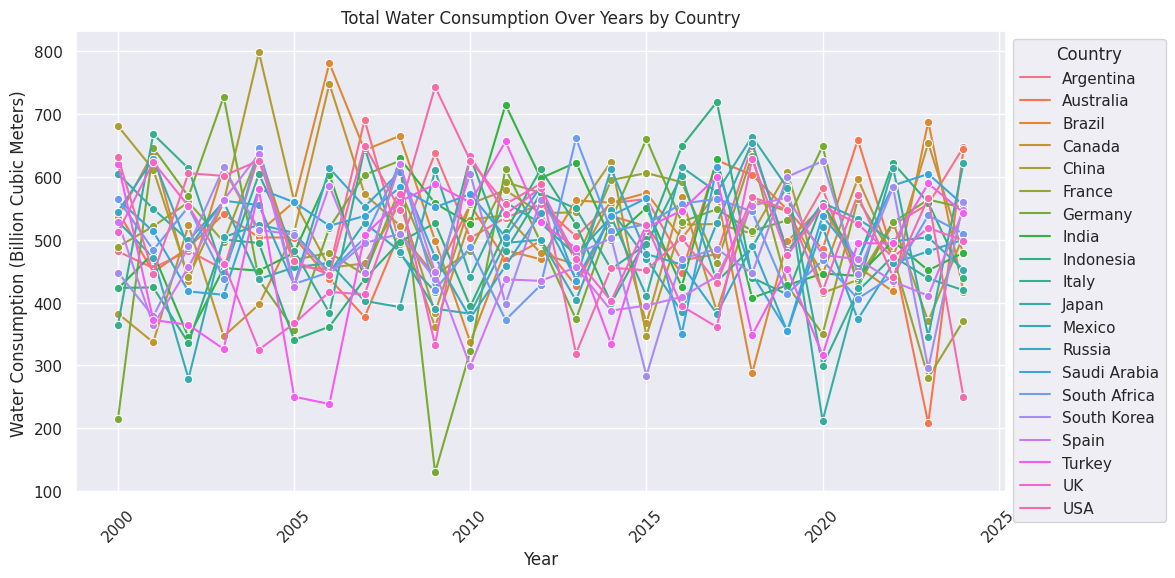

In [12]:
# Convert Year to integer for consistency
df['Year'] = df['Year'].astype(int)

# Set Seaborn style
sns.set_theme(style="darkgrid")

# 1. Total Water Consumption Over Time for Each Country
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Total Water Consumption (Billion Cubic Meters)', hue='Country', marker='o')
plt.title('Total Water Consumption Over Years by Country')
plt.xlabel('Year')
plt.ylabel('Water Consumption (Billion Cubic Meters)')
plt.legend(title='Country', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.show()


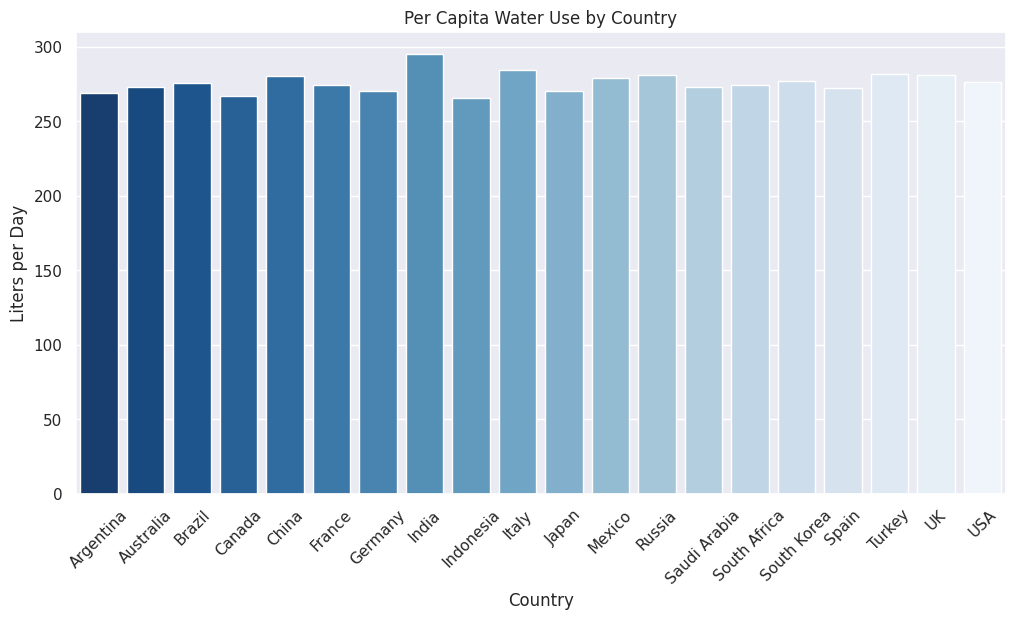

In [13]:
# 2. Per Capita Water Use by Country
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Country', y='Per Capita Water Use (Liters per Day)', ci=None, palette='Blues_r')
plt.title('Per Capita Water Use by Country')
plt.xlabel('Country')
plt.ylabel('Liters per Day')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x600 with 0 Axes>

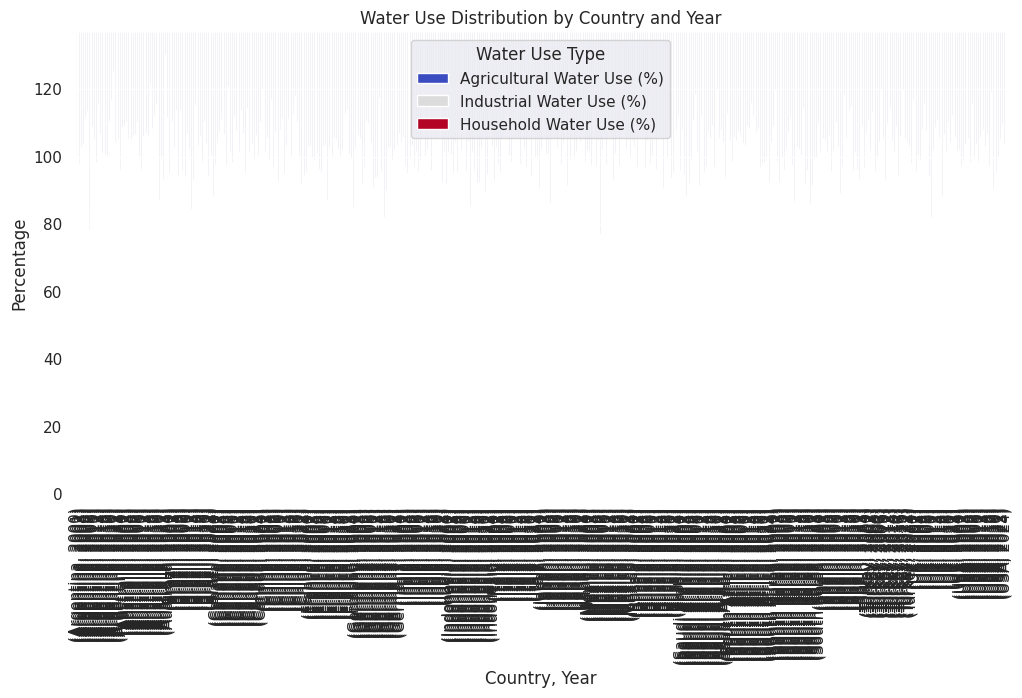

In [14]:
# 3. Stacked Bar Chart for Water Use Distribution
plt.figure(figsize=(12, 6))
water_use_columns = ['Agricultural Water Use (%)', 'Industrial Water Use (%)', 'Household Water Use (%)']
df.set_index(['Country', 'Year'])[water_use_columns].plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(12, 6))
plt.title('Water Use Distribution by Country and Year')
plt.ylabel('Percentage')
plt.xlabel('Country, Year')
plt.legend(title='Water Use Type')
plt.xticks(rotation=90)
plt.show()

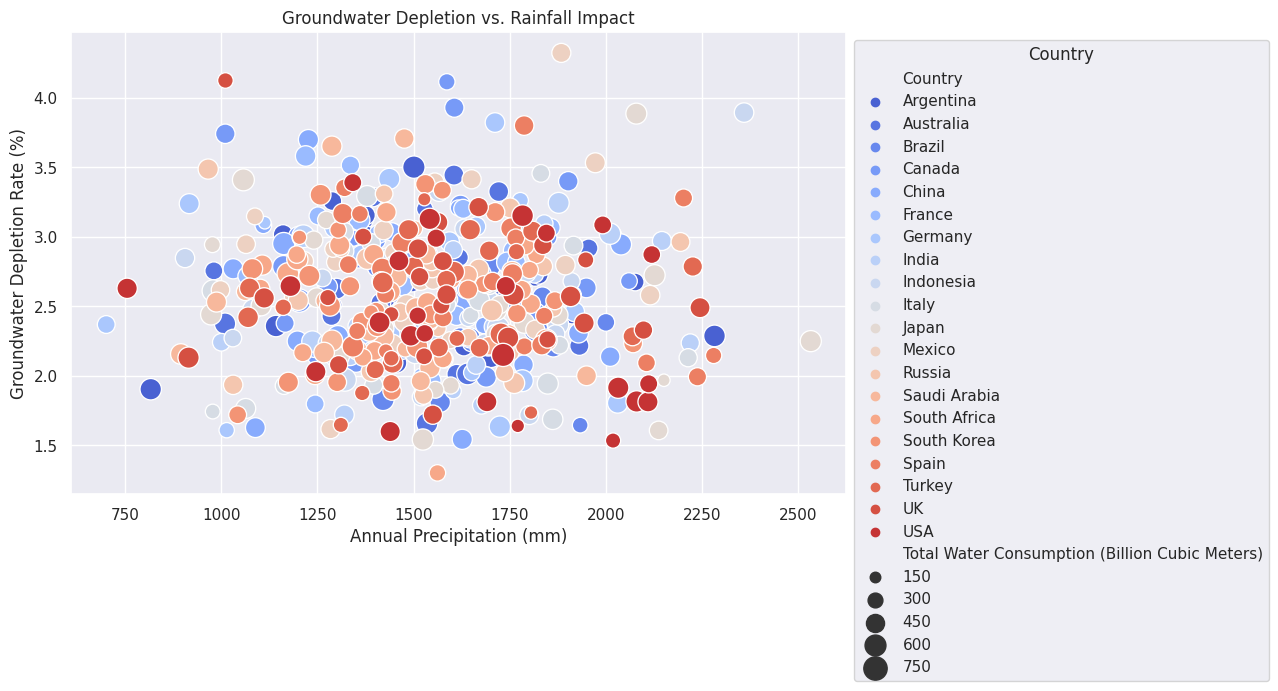

In [15]:
# 4. Scatter Plot: Groundwater Depletion vs. Rainfall Impact
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall Impact (Annual Precipitation in mm)', 
                y='Groundwater Depletion Rate (%)', hue='Country', size='Total Water Consumption (Billion Cubic Meters)', palette='coolwarm', sizes=(50, 300))
plt.title('Groundwater Depletion vs. Rainfall Impact')
plt.xlabel('Annual Precipitation (mm)')
plt.ylabel('Groundwater Depletion Rate (%)')
plt.legend(title='Country', bbox_to_anchor=(1, 1))
plt.show()

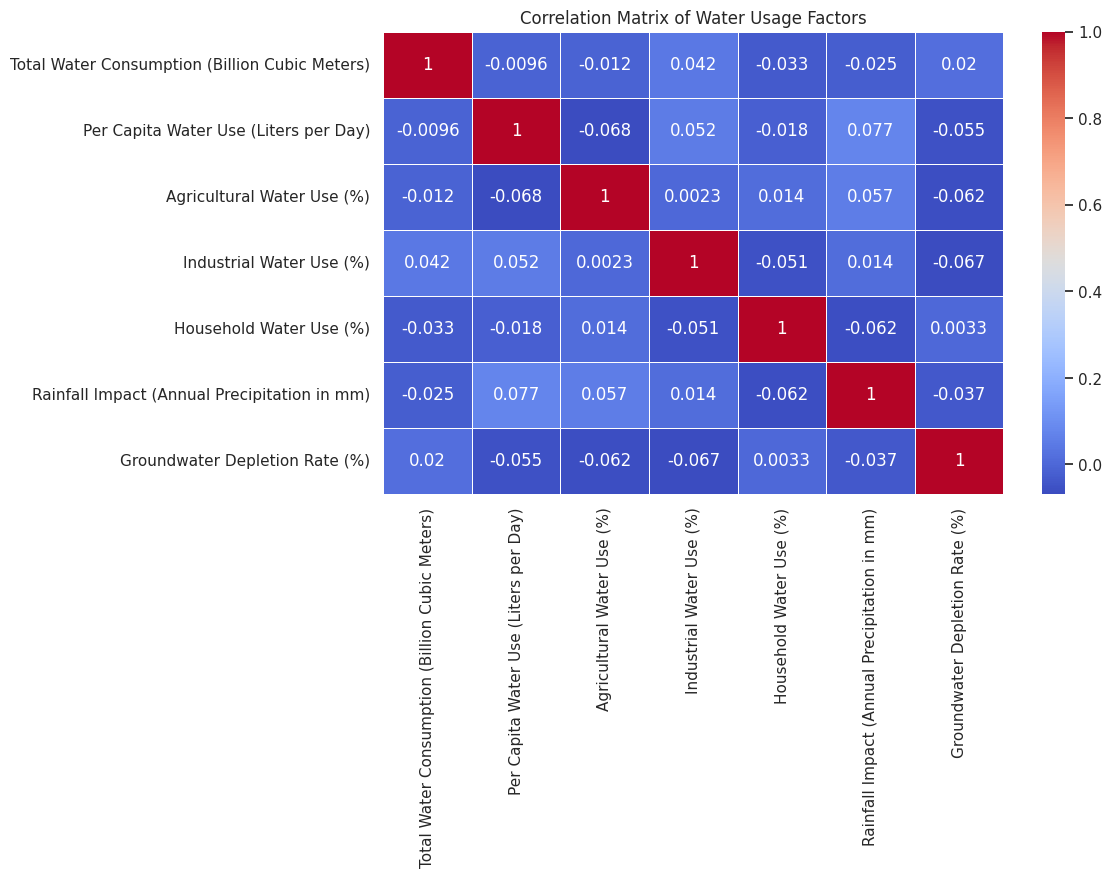

In [16]:
# 5. Correlation Heatmap
plt.figure(figsize=(10, 6))
corr_matrix = df.drop(columns=['Country', 'Year']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Water Usage Factors')
plt.show()

In [17]:
import plotly.express as px

# Rename the column for easier usage
df.rename(columns={"Total Water Consumption (Billion Cubic Meters)": "Water Consumption"}, inplace=True)

# Verify the renaming worked
print(df.columns)

# Create the choropleth map
fig = px.choropleth(df, 
                    locations="Country", 
                    locationmode="country names",  
                    color="Water Consumption", 
                    hover_name="Country",  
                    animation_frame="Year", 
                    color_continuous_scale="Viridis")

# Display the map
fig.show(renderer="iframe")

Index(['Country', 'Year', 'Water Consumption',
       'Per Capita Water Use (Liters per Day)', 'Agricultural Water Use (%)',
       'Industrial Water Use (%)', 'Household Water Use (%)',
       'Rainfall Impact (Annual Precipitation in mm)',
       'Groundwater Depletion Rate (%)'],
      dtype='object')


## Predictive Modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
feature_cols = [
    'Year',  
    'Per Capita Water Use (Liters per Day)',
    'Agricultural Water Use (%)',
    'Industrial Water Use (%)',
    'Household Water Use (%)',
    'Rainfall Impact (Annual Precipitation in mm)',
    'Groundwater Depletion Rate (%)'
]

In [20]:
for col in feature_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required feature column: {col}")

In [21]:
print(df.columns)

Index(['Country', 'Year', 'Water Consumption',
       'Per Capita Water Use (Liters per Day)', 'Agricultural Water Use (%)',
       'Industrial Water Use (%)', 'Household Water Use (%)',
       'Rainfall Impact (Annual Precipitation in mm)',
       'Groundwater Depletion Rate (%)'],
      dtype='object')


In [22]:
print(df.columns.tolist())

['Country', 'Year', 'Water Consumption', 'Per Capita Water Use (Liters per Day)', 'Agricultural Water Use (%)', 'Industrial Water Use (%)', 'Household Water Use (%)', 'Rainfall Impact (Annual Precipitation in mm)', 'Groundwater Depletion Rate (%)']


In [23]:
X = df[feature_cols]
y = df["Water Consumption"]

In [24]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Standardizing numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Initializing ML models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [27]:
# Store model results
results = []

In [28]:
# Training and evaluating models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, r2])

# Convert results into a DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'MSE', 'R² Score'])

# Display results
print(results_df)

                      Model         MAE           MSE  R² Score
0         Linear Regression   76.282529   9816.028024 -0.027809
1             Decision Tree  119.369938  23178.481012 -1.426954
2             Random Forest   77.509139  10118.100399 -0.059438
3  Support Vector Regressor   75.482637   9610.208587 -0.006258
4         Gradient Boosting   81.748913  11405.731955 -0.194262


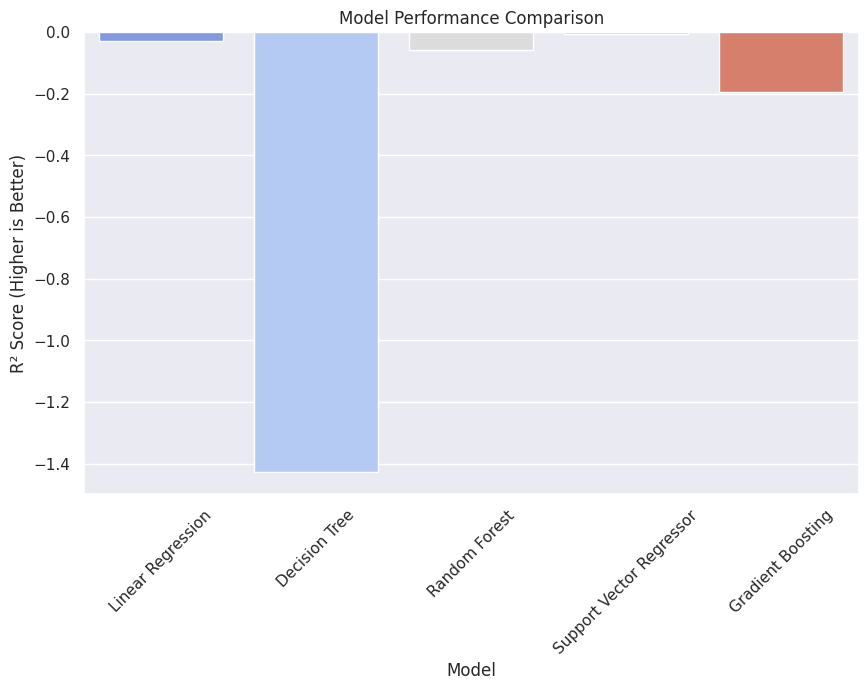

In [29]:
# Plot results in a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="R² Score", data=results_df, palette="coolwarm")
plt.ylabel("R² Score (Higher is Better)")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()

## Thank you!!!....upvote!!!